# Data Exploration

Now that we have determined our feature importances, we'll explore our data visually.

### Common Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pkl
import tkinter as tk
from tkinter import filedialog

In [2]:
# suppress warnings
import warnings

warnings.filterwarnings("ignore")

### 1. Load Data

In [3]:
df = pkl.load(open("../../../data/2021/interim/vbac/filtered_df.pkl", "rb"))
target = pkl.load(open("../../../data/2021/interim/vbac/target.pkl", "rb"))
feature_importances_df = pkl.load(
    open("../../../data/2021/processed/vbac/feature_importances_df.pkl", "rb")
)

In [4]:
df["target"] = target

### Feature Selection

We'll choose our top features by filtering for any with an importance > 0.01

In [5]:
top_features = feature_importances_df[feature_importances_df["importance"] > 0.01]

top_features

,feature,importance
114,Categorical Pipeline__augmentation_of_labor_1.0,0.245588
125,Categorical Pipeline__attendant_at_birth_3.0,0.203596
113,Categorical Pipeline__induction_of_labor_1.0,0.148179
157,Numerical Pipeline__time_of_birth,0.095961
177,Numerical Pipeline__number_of_previous_cesarean,0.062965
18,Categorical Pipeline__birth_place_3.0,0.043473
178,Numerical Pipeline__combined_gestation_detail_...,0.030385
126,Categorical Pipeline__attendant_at_birth_4.0,0.029246
160,Numerical Pipeline__prior_births_now_living,0.026663
16,Categorical Pipeline__birth_day_of_week_7.0,0.014876


Based on domain knowledge, we'll also investigate:

- Birth Weight in Grams

We'll explore each of these in order.

### Cleaning Up Encoded NAs

We'd like to view the raw data with NAs included for now, but some columns we're interested in have encoded missing values in a way that we need to account for manually.

We'll skip analysis of delivery_weight_recode, as it is directly related to BMI.

In [6]:
df["augmentation_of_labor"] = df["augmentation_of_labor"].replace(9, np.nan)
df["attendant_at_birth"] = df["attendant_at_birth"].replace(9, np.nan)
df["induction_of_labor"] = df["induction_of_labor"].replace(9, np.nan)
df["time_of_birth"] = df["time_of_birth"].replace(9999, np.nan)
df["number_of_previous_cesarean"] = df["number_of_previous_cesarean"].replace(
    99, np.nan
)
df["birth_place"] = df["birth_place"].replace(9, np.nan)
df["combined_gestation_detail_in_weeks"] = df[
    "combined_gestation_detail_in_weeks"
].replace(99, np.nan)
df["prior_births_now_living"] = df["prior_births_now_living"].replace(99, np.nan)
df["birth_day_of_week"] = df["birth_day_of_week"].replace(9, np.nan)
df["fetal_presentation_at_delivery"] = df["fetal_presentation_at_delivery"].replace(
    9, np.nan
)
df["BMI"] = df["BMI"].replace(99, np.nan)
df["birth_weight_in_grams"] = df["birth_weight_in_grams"].replace(9999, np.nan)

In [7]:
missing_values_df = df.isna().sum().reset_index()

missing_values_df

,index,0
0,birth_month,0
1,time_of_birth,15
2,birth_day_of_week,0
3,birth_place,16
4,mothers_single_year_age,0
...,...,...
76,down_syndrome,829
77,suspected_chromosomal_disorder,829
78,hypospadias,829
79,no_congenital_abnormalities_reported,0


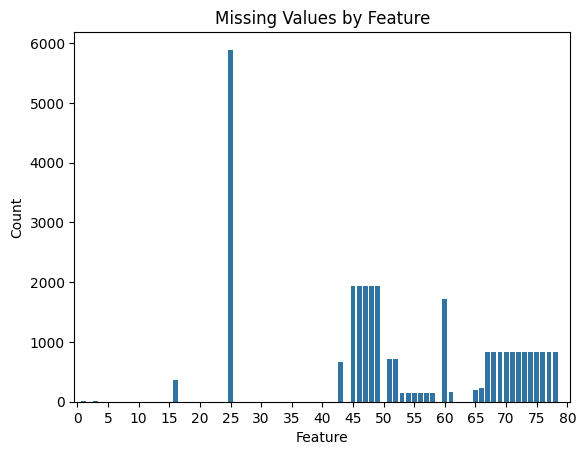

In [8]:
missing_values_ax = sns.barplot(
    data=missing_values_df,
    x=missing_values_df.index,
    y=0,
)
missing_values_ax.set_title("Missing Values by Feature")
missing_values_ax.set_xlabel("Feature")
missing_values_ax.set_ylabel("Count")
missing_values_ax.set_xticks(range(0, len(missing_values_df.index), 5))
plt.show()

### Univariate Visualization

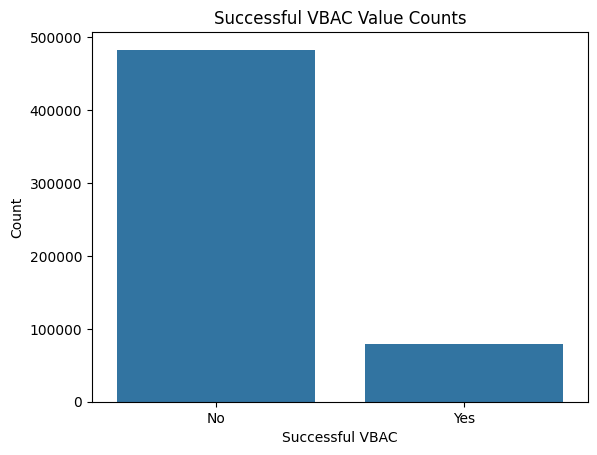

In [9]:
target_value_counts = df["target"].value_counts()

target_bar_ax = sns.barplot(x=target_value_counts.index, y=target_value_counts.values)
target_bar_ax.set_title("Successful VBAC Value Counts")
target_bar_ax.set_xlabel("Successful VBAC")
target_bar_ax.set_ylabel("Count")
target_bar_ax.set_xticklabels(["No", "Yes"])
plt.show()

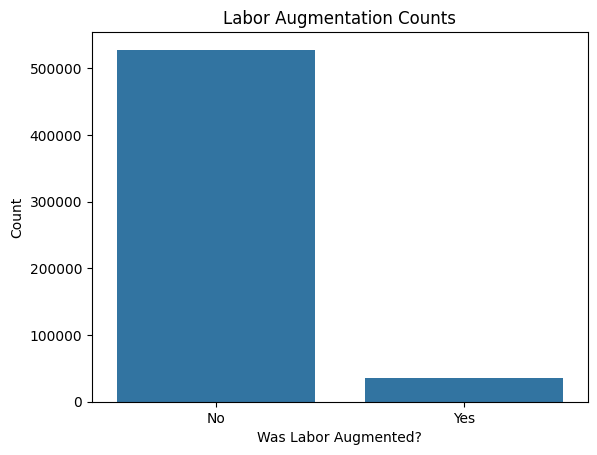

In [10]:
augmentation_of_labor_value_counts = df["augmentation_of_labor"].value_counts()

labor_augmentation_bar_ax = sns.barplot(
    x=augmentation_of_labor_value_counts.index,
    y=augmentation_of_labor_value_counts.values,
)
labor_augmentation_bar_ax.set_title("Labor Augmentation Counts")
labor_augmentation_bar_ax.set_xlabel("Was Labor Augmented?")
labor_augmentation_bar_ax.set_xticklabels(["No", "Yes"])
labor_augmentation_bar_ax.set_ylabel("Count")
plt.show()

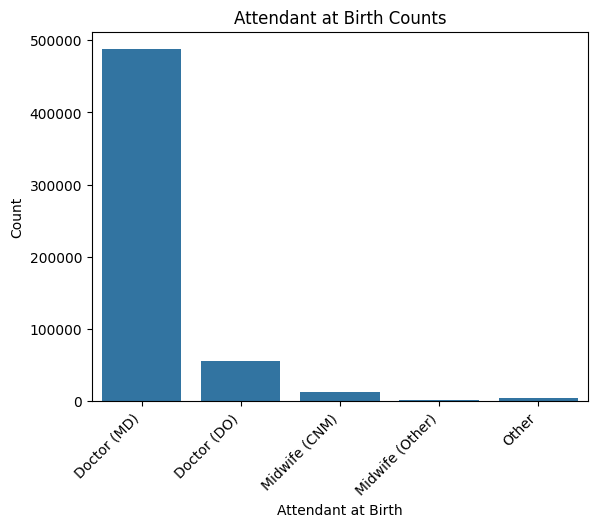

In [11]:
attendant_at_birth_value_counts = df["attendant_at_birth"].value_counts()

attendant_at_birth_bar_ax = sns.barplot(
    x=attendant_at_birth_value_counts.index,
    y=attendant_at_birth_value_counts.values,
)
attendant_at_birth_bar_ax.set_title("Attendant at Birth Counts")
attendant_at_birth_bar_ax.set_xlabel("Attendant at Birth")
attendant_at_birth_bar_ax.set_xticklabels(
    [
        "Doctor (MD)",
        "Doctor (DO)",
        "Midwife (CNM)",
        "Midwife (Other)",
        "Other",
    ],
    rotation=45,
    ha="right",
)

attendant_at_birth_bar_ax.set_ylabel("Count")
plt.show()

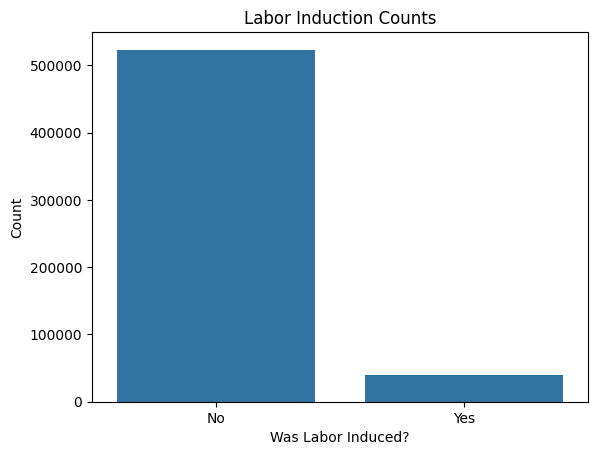

In [12]:
induction_of_labor_value_counts = df["induction_of_labor"].value_counts()

induction_of_labor_bar_ax = sns.barplot(
    x=induction_of_labor_value_counts.index,
    y=induction_of_labor_value_counts.values,
)
induction_of_labor_bar_ax.set_title("Labor Induction Counts")
induction_of_labor_bar_ax.set_xlabel("Was Labor Induced?")
induction_of_labor_bar_ax.set_xticklabels(["No", "Yes"])
induction_of_labor_bar_ax.set_ylabel("Count")
plt.show()

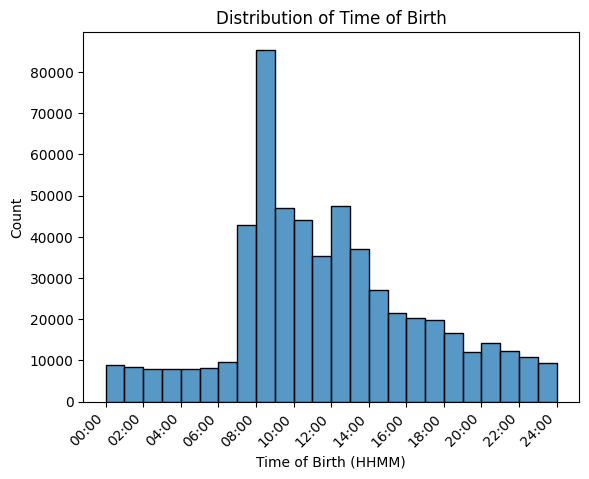

In [13]:
time_of_birth_value_counts = df["time_of_birth"].value_counts()

time_of_birth_bar_ax = sns.histplot(
    x=time_of_birth_value_counts.index,
    weights=time_of_birth_value_counts.values,
    bins=range(0, 2401, 100),
)
time_of_birth_bar_ax.set_title("Distribution of Time of Birth")
time_of_birth_bar_ax.set_xlabel("Time of Birth (HHMM)")
time_of_birth_bar_ax.set_xticks(
    ticks=range(0, 2401, 200),
    labels=[f"{int(hour):02d}:00" for hour in range(0, 25, 2)],
    rotation=45,
    ha="right",
)
time_of_birth_bar_ax.set_ylabel("Count")
plt.show()

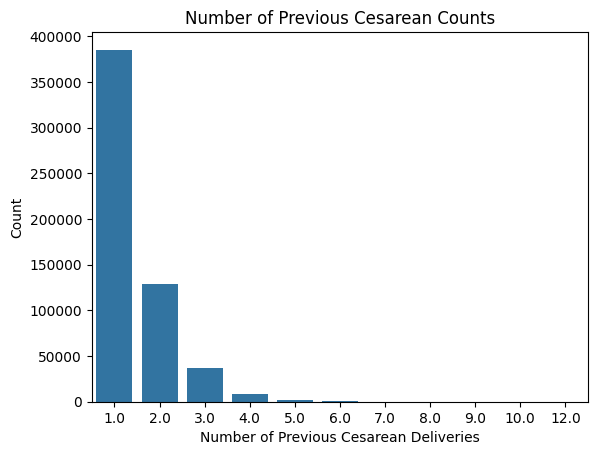

In [14]:
number_of_previous_cesarean_value_counts = df[
    "number_of_previous_cesarean"
].value_counts()

number_of_previous_cesarean_bar_ax = sns.barplot(
    x=number_of_previous_cesarean_value_counts.index,
    y=number_of_previous_cesarean_value_counts.values,
)
number_of_previous_cesarean_bar_ax.set_title("Number of Previous Cesarean Counts")
number_of_previous_cesarean_bar_ax.set_xlabel("Number of Previous Cesarean Deliveries")
number_of_previous_cesarean_bar_ax.set_ylabel("Count")
plt.show()

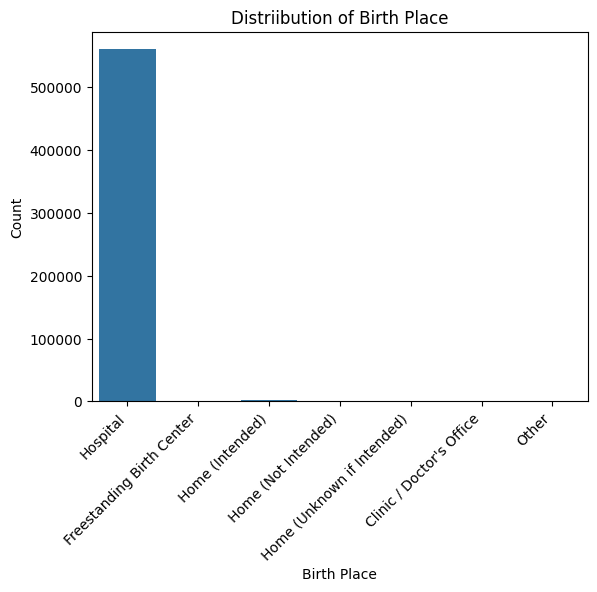

In [15]:
birth_place_value_counts = df["birth_place"].value_counts()

birth_place_bar_ax = sns.barplot(
    x=birth_place_value_counts.index,
    y=birth_place_value_counts.values,
)
birth_place_bar_ax.set_title("Distriibution of Birth Place")
birth_place_bar_ax.set_xlabel("Birth Place")
birth_place_bar_ax.set_xticklabels(
    [
        "Hospital",
        "Freestanding Birth Center",
        "Home (Intended)",
        "Home (Not Intended)",
        "Home (Unknown if Intended)",
        "Clinic / Doctor's Office",
        "Other",
    ],
    rotation=45,
    ha="right",
)
birth_place_bar_ax.set_ylabel("Count")
plt.show()

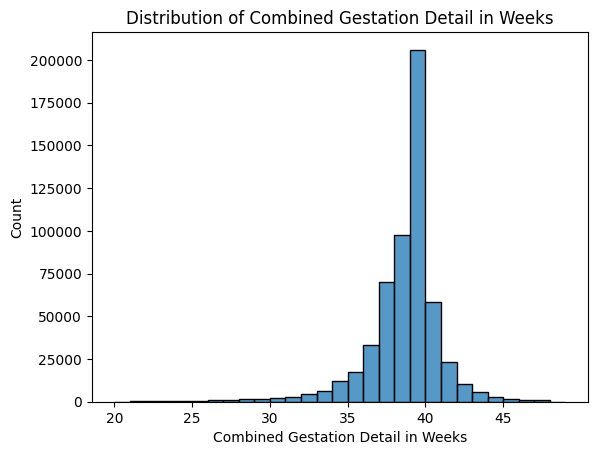

In [16]:
combined_gestation_detail_value_counts = df[
    "combined_gestation_detail_in_weeks"
].value_counts()

combined_gestation_detail_bar_ax = sns.histplot(
    x=combined_gestation_detail_value_counts.index,
    weights=combined_gestation_detail_value_counts.values,
    bins=range(20, 50, 1),
)
combined_gestation_detail_bar_ax.set_title(
    "Distribution of Combined Gestation Detail in Weeks"
)
combined_gestation_detail_bar_ax.set_xlabel("Combined Gestation Detail in Weeks")
combined_gestation_detail_bar_ax.set_xticks(ticks=range(20, 50, 5))
combined_gestation_detail_bar_ax.set_ylabel("Count")
plt.show()

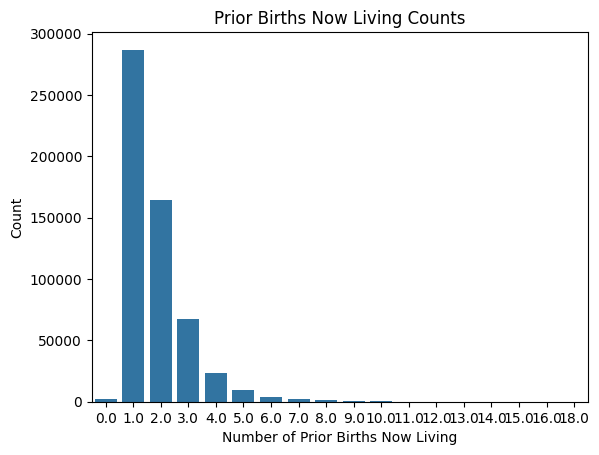

In [17]:
prior_births_now_living_value_counts = df["prior_births_now_living"][
    df["prior_births_now_living"] != 99
].value_counts()

prior_births_now_living_bar_ax = sns.barplot(
    x=prior_births_now_living_value_counts.index,
    y=prior_births_now_living_value_counts.values,
)
prior_births_now_living_bar_ax.set_title("Prior Births Now Living Counts")
prior_births_now_living_bar_ax.set_xlabel("Number of Prior Births Now Living")
prior_births_now_living_bar_ax.set_ylabel("Count")
plt.show()

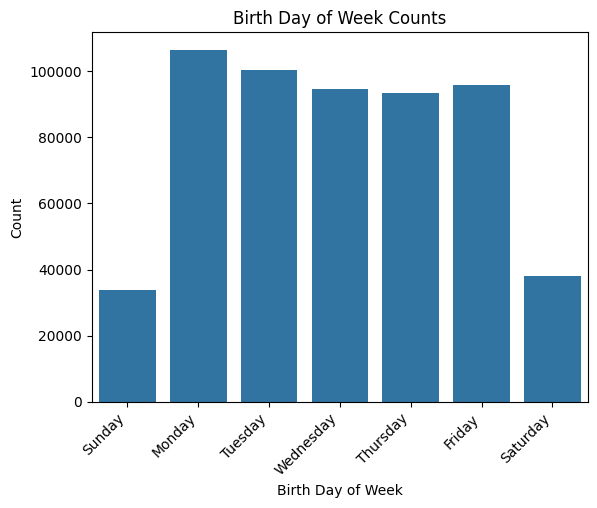

In [18]:
birth_day_of_week_value_counts = df["birth_day_of_week"].value_counts()

birth_day_of_week_bar_ax = sns.barplot(
    x=birth_day_of_week_value_counts.index,
    y=birth_day_of_week_value_counts.values,
)
birth_day_of_week_bar_ax.set_title("Birth Day of Week Counts")
birth_day_of_week_bar_ax.set_xlabel("Birth Day of Week")
birth_day_of_week_bar_ax.set_xticklabels(
    [
        "Sunday",
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
    ],
    rotation=45,
    ha="right",
)
birth_day_of_week_bar_ax.set_ylabel("Count")
plt.show()

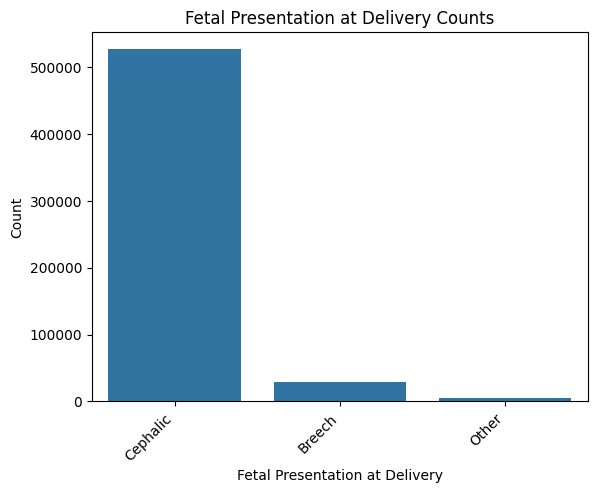

In [19]:
fetal_presentation_at_delivery_value_counts = df[
    "fetal_presentation_at_delivery"
].value_counts()

fetal_presentation_at_delivery_bar_ax = sns.barplot(
    x=fetal_presentation_at_delivery_value_counts.index,
    y=fetal_presentation_at_delivery_value_counts.values,
)
fetal_presentation_at_delivery_bar_ax.set_title("Fetal Presentation at Delivery Counts")
fetal_presentation_at_delivery_bar_ax.set_xlabel("Fetal Presentation at Delivery")
fetal_presentation_at_delivery_bar_ax.set_xticklabels(
    ["Cephalic", "Breech", "Other"],
    rotation=45,
    ha="right",
)
fetal_presentation_at_delivery_bar_ax.set_ylabel("Count")
plt.show()

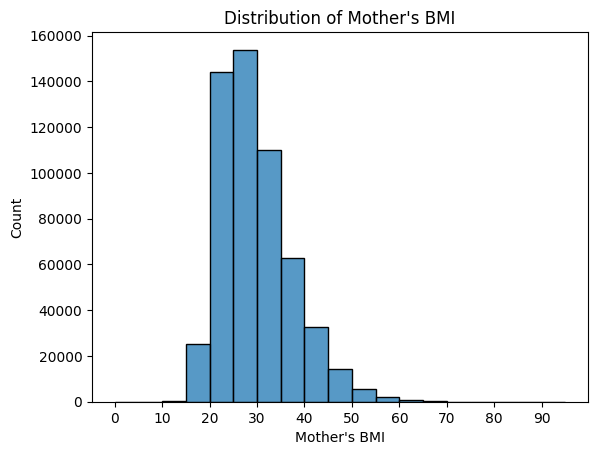

In [20]:
BMI_value_counts = df["BMI"].value_counts()

BMI_bar_ax = sns.histplot(
    x=BMI_value_counts.index, weights=BMI_value_counts.values, bins=range(0, 100, 5)
)
BMI_bar_ax.set_title("Distribution of Mother's BMI")
BMI_bar_ax.set_xlabel("Mother's BMI")
BMI_bar_ax.set_xticks(ticks=range(0, 100, 10))
BMI_bar_ax.set_ylabel("Count")
plt.show()

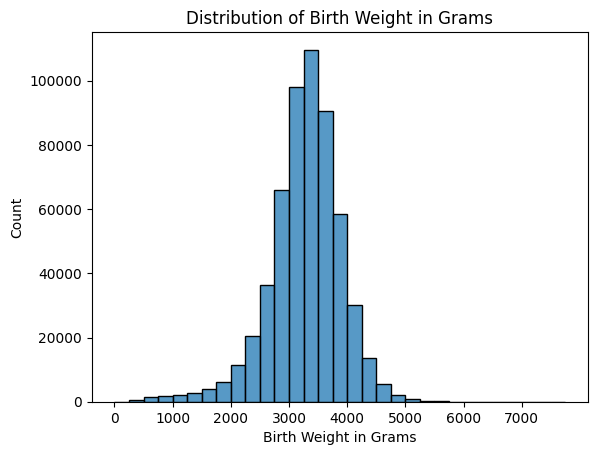

In [21]:
birth_weight_in_grams_value_counts = df["birth_weight_in_grams"].value_counts()

birth_weight_in_grams_bar_ax = sns.histplot(
    x=birth_weight_in_grams_value_counts.index,
    weights=birth_weight_in_grams_value_counts.values,
    bins=range(0, 8000, 250),
)
birth_weight_in_grams_bar_ax.set_title("Distribution of Birth Weight in Grams")
birth_weight_in_grams_bar_ax.set_xlabel("Birth Weight in Grams")
birth_weight_in_grams_bar_ax.set_xticks(ticks=range(0, 8000, 1000))
birth_weight_in_grams_bar_ax.set_ylabel("Count")
plt.show()

### Bivariate Visualizations

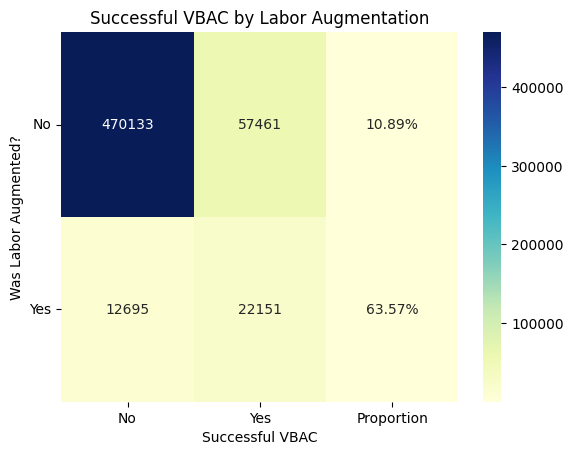

In [22]:
augmentation_of_labor_cross_tab = pd.crosstab(df["augmentation_of_labor"], target)

augmentation_of_labor_cross_tab["proportion"] = (
    augmentation_of_labor_cross_tab[1]
    / (augmentation_of_labor_cross_tab[0] + augmentation_of_labor_cross_tab[1])
    * 100
)

annotation_matrix = augmentation_of_labor_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    augmentation_of_labor_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

augmentation_of_labor_cross_tab_ax = sns.heatmap(
    augmentation_of_labor_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
augmentation_of_labor_cross_tab_ax.set_title("Successful VBAC by Labor Augmentation")
augmentation_of_labor_cross_tab_ax.set_xlabel("Successful VBAC")
augmentation_of_labor_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
augmentation_of_labor_cross_tab_ax.set_ylabel("Was Labor Augmented?")
augmentation_of_labor_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Labor is not augmented in most cases; however, when it is augmented, it results in significantly more sucessful VBACs.

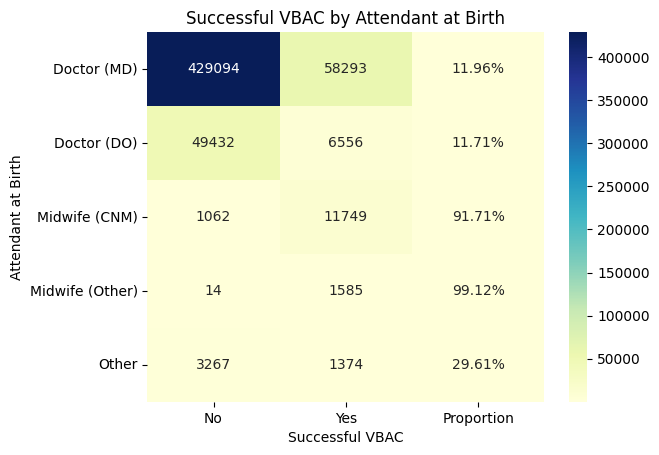

In [23]:
attendant_at_birth_cross_tab = pd.crosstab(
    df["attendant_at_birth"][df["attendant_at_birth"] != 9], target
)
attendant_at_birth_cross_tab["proportion"] = (
    attendant_at_birth_cross_tab[1]
    / (attendant_at_birth_cross_tab[0] + attendant_at_birth_cross_tab[1])
    * 100
)

annotation_matrix = attendant_at_birth_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(attendant_at_birth_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

attendant_at_birth_cross_tab_ax = sns.heatmap(
    attendant_at_birth_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
attendant_at_birth_cross_tab_ax.set_title("Successful VBAC by Attendant at Birth")
attendant_at_birth_cross_tab_ax.set_xlabel("Successful VBAC")
attendant_at_birth_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
attendant_at_birth_cross_tab_ax.set_ylabel("Attendant at Birth")
attendant_at_birth_cross_tab_ax.set_yticklabels(
    [
        "Doctor (MD)",
        "Doctor (DO)",
        "Midwife (CNM)",
        "Midwife (Other)",
        "Other",
    ],
    rotation=0,
)
plt.show()

When a midwife is the birth attendant, the expectant mother is more likely to have a successful VBAC. However, it's important to note that midwives are unable to perform c-sections, so it may be the case that the birthing mother may attempt a vaginal delivery for longer than she might under the supervision of an attendant who can perform surgery.

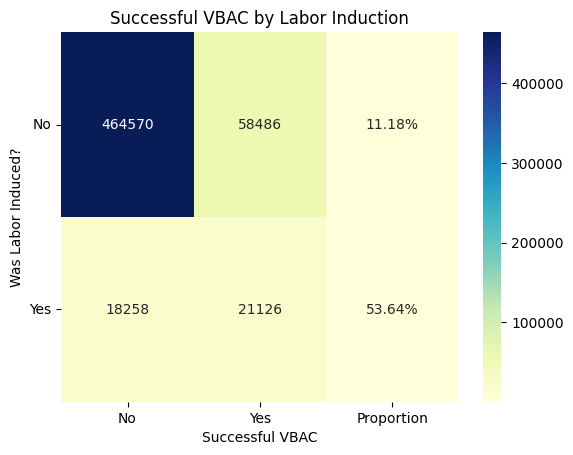

In [24]:
induction_of_labor_cross_tab = pd.crosstab(df["induction_of_labor"], target)

induction_of_labor_cross_tab["proportion"] = (
    induction_of_labor_cross_tab[1]
    / (induction_of_labor_cross_tab[0] + induction_of_labor_cross_tab[1])
    * 100
)

annotation_matrix = induction_of_labor_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(induction_of_labor_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

induction_of_labor_cross_tab_ax = sns.heatmap(
    induction_of_labor_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
induction_of_labor_cross_tab_ax.set_title("Successful VBAC by Labor Induction")
induction_of_labor_cross_tab_ax.set_xlabel("Successful VBAC")
induction_of_labor_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
induction_of_labor_cross_tab_ax.set_ylabel("Was Labor Induced?")
induction_of_labor_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Labor Induction also results in a significant increase in VBAC success, though not as significant as labor augmentation.

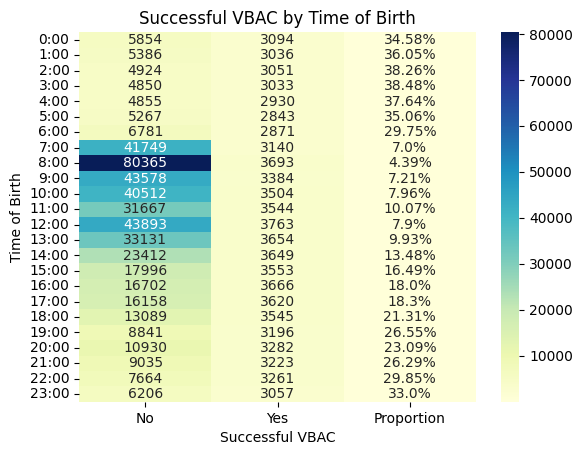

In [25]:
time_of_birth_cross_tab = pd.crosstab(
    pd.cut(
        df["time_of_birth"],
        bins=range(0, 2401, 100),
        labels=[f"{i}:00" for i in range(24)],
    ),
    target,
)
time_of_birth_cross_tab["proportion"] = (
    time_of_birth_cross_tab[1]
    / (time_of_birth_cross_tab[0] + time_of_birth_cross_tab[1])
    * 100
)

annotation_matrix = time_of_birth_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(time_of_birth_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

time_of_birth_cross_tab_ax = sns.heatmap(
    time_of_birth_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
time_of_birth_cross_tab_ax.set_title("Successful VBAC by Time of Birth")
time_of_birth_cross_tab_ax.set_xlabel("Successful VBAC")
time_of_birth_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
time_of_birth_cross_tab_ax.set_ylabel("Time of Birth")
time_of_birth_cross_tab_ax.set_yticklabels(time_of_birth_cross_tab.index, rotation=0)
plt.show()

There is no particular time of day that is more likely to result in a successful VBAC. However, a c-section is more likely to occur during business hours. This is likely the result of pre-scheduled c-sections.

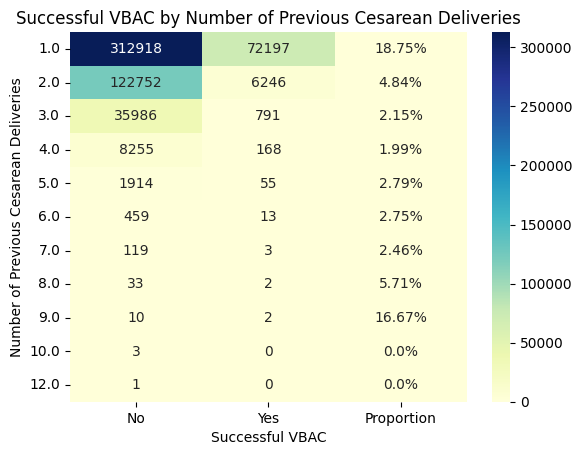

In [26]:
number_of_previous_cesarean_cross_tab = pd.crosstab(
    df["number_of_previous_cesarean"][df["number_of_previous_cesarean"] != 99],
    target,
)
number_of_previous_cesarean_cross_tab["proportion"] = (
    number_of_previous_cesarean_cross_tab[1]
    / (
        number_of_previous_cesarean_cross_tab[0]
        + number_of_previous_cesarean_cross_tab[1]
    )
    * 100
)

annotation_matrix = number_of_previous_cesarean_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    number_of_previous_cesarean_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

number_of_previous_cesarean_cross_tab_ax = sns.heatmap(
    number_of_previous_cesarean_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
number_of_previous_cesarean_cross_tab_ax.set_title(
    "Successful VBAC by Number of Previous Cesarean Deliveries"
)
number_of_previous_cesarean_cross_tab_ax.set_xlabel("Successful VBAC")
number_of_previous_cesarean_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
number_of_previous_cesarean_cross_tab_ax.set_ylabel(
    "Number of Previous Cesarean Deliveries"
)
number_of_previous_cesarean_cross_tab_ax.set_yticklabels(
    number_of_previous_cesarean_cross_tab.index, rotation=0
)
plt.show()

The more c-sections a mother has had, the less likely she is to have a successful VBAC.

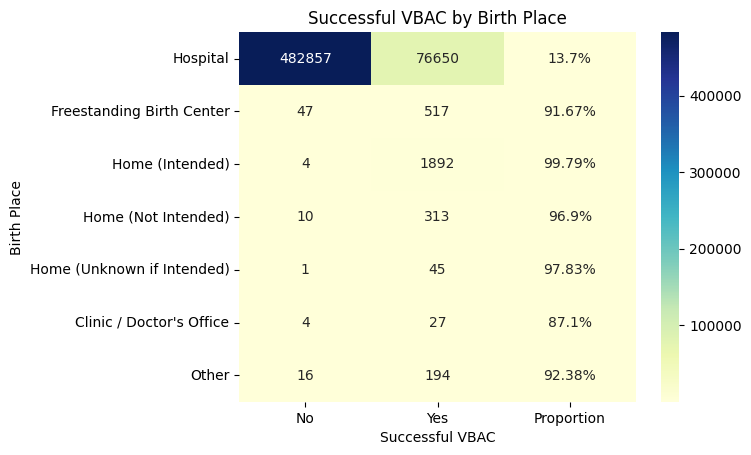

In [27]:
birth_place_cross_tab = pd.crosstab(df["birth_place"], target)

birth_place_cross_tab["proportion"] = (
    birth_place_cross_tab[1]
    / (birth_place_cross_tab[0] + birth_place_cross_tab[1])
    * 100
)

annotation_matrix = birth_place_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(birth_place_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

birth_place_cross_tab_ax = sns.heatmap(
    birth_place_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
birth_place_cross_tab_ax.set_title("Successful VBAC by Birth Place")
birth_place_cross_tab_ax.set_xlabel("Successful VBAC")
birth_place_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
birth_place_cross_tab_ax.set_ylabel("Birth Place")
birth_place_cross_tab_ax.set_yticklabels(
    [
        "Hospital",
        "Freestanding Birth Center",
        "Home (Intended)",
        "Home (Not Intended)",
        "Home (Unknown if Intended)",
        "Clinic / Doctor's Office",
        "Other",
    ],
    rotation=0,
)
plt.show()

A VBAC is most likely to occur at home when the mother has planned ahead for it. However, we do not find these data points to be useful, as it's expected that a hospital would be the primary location for a c-section, and that other locations would have low rates of c-sections.

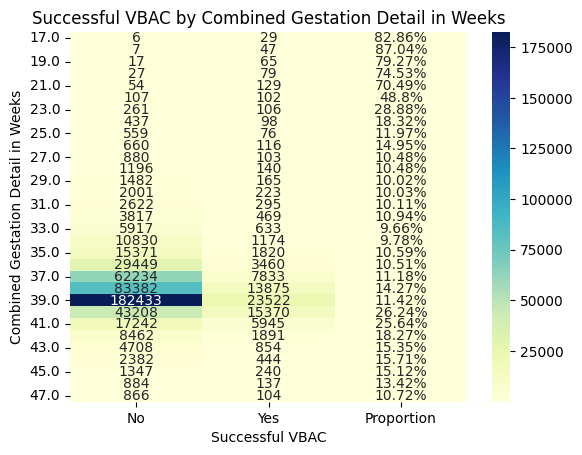

In [28]:
combined_gestation_detail_cross_tab = pd.crosstab(
    df["combined_gestation_detail_in_weeks"],
    target,
)
combined_gestation_detail_cross_tab["proportion"] = (
    combined_gestation_detail_cross_tab[1]
    / (combined_gestation_detail_cross_tab[0] + combined_gestation_detail_cross_tab[1])
) * 100

annotation_matrix = combined_gestation_detail_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    combined_gestation_detail_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

combined_gestation_detail_cross_tab_ax = sns.heatmap(
    combined_gestation_detail_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
combined_gestation_detail_cross_tab_ax.set_title(
    "Successful VBAC by Combined Gestation Detail in Weeks"
)
combined_gestation_detail_cross_tab_ax.set_xlabel("Successful VBAC")
combined_gestation_detail_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
combined_gestation_detail_cross_tab_ax.set_ylabel("Combined Gestation Detail in Weeks")
plt.show()

Preterm deliveries are most likely to result in a VBAC; however, we would not consider these to be "successful", as deliveries prior to 28 weeks gestation have a near-100% chance of mortality.

Of term or near-term deliveries, those at 40-41 weeks are most likely to have successful VBACs.

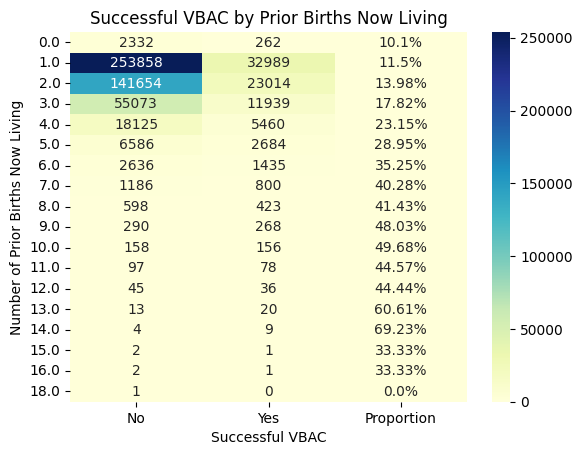

In [29]:
prior_births_now_living_cross_tab = pd.crosstab(
    df["prior_births_now_living"][df["prior_births_now_living"] != 99], target
)

prior_births_now_living_cross_tab["proportion"] = (
    prior_births_now_living_cross_tab[1]
    / (prior_births_now_living_cross_tab[0] + prior_births_now_living_cross_tab[1])
) * 100

annotation_matrix = prior_births_now_living_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    prior_births_now_living_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

prior_births_now_living_cross_tab_ax = sns.heatmap(
    prior_births_now_living_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
prior_births_now_living_cross_tab_ax.set_title(
    "Successful VBAC by Prior Births Now Living"
)
prior_births_now_living_cross_tab_ax.set_xlabel("Successful VBAC")
prior_births_now_living_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
prior_births_now_living_cross_tab_ax.set_ylabel("Number of Prior Births Now Living")
prior_births_now_living_cross_tab_ax.set_yticklabels(
    prior_births_now_living_cross_tab.index, rotation=0
)
plt.show()

The more children a mother has borne, the more likely she is to have a successful VBAC. This is counterintuitive, but our suspicion is that this may be better explored in the multivariate visualizations in conjunction with number of previous c-sections.

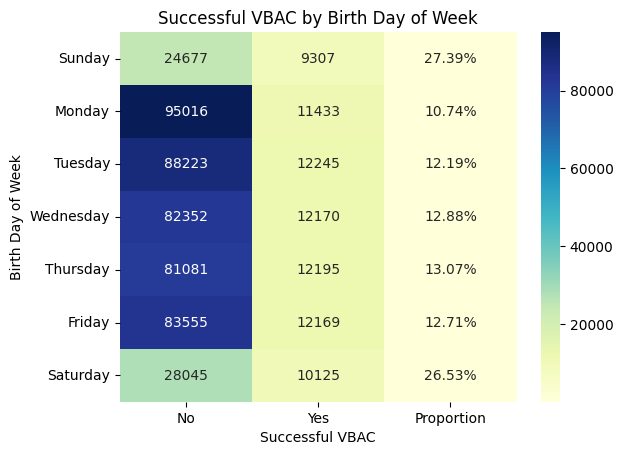

In [30]:
birth_day_of_week_cross_tab = pd.crosstab(df["birth_day_of_week"], target)

birth_day_of_week_cross_tab["proportion"] = (
    birth_day_of_week_cross_tab[1]
    / (birth_day_of_week_cross_tab[0] + birth_day_of_week_cross_tab[1])
    * 100
)

annotation_matrix = birth_day_of_week_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(birth_day_of_week_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

birth_day_of_week_cross_tab_ax = sns.heatmap(
    birth_day_of_week_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
birth_day_of_week_cross_tab_ax.set_title("Successful VBAC by Birth Day of Week")
birth_day_of_week_cross_tab_ax.set_xlabel("Successful VBAC")
birth_day_of_week_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
birth_day_of_week_cross_tab_ax.set_ylabel("Birth Day of Week")
birth_day_of_week_cross_tab_ax.set_yticklabels(
    [
        "Sunday",
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
    ],
    rotation=0,
)
plt.show()

Weekdays have a higher rate of c-sections, which is expected due to scheduled c-sections.

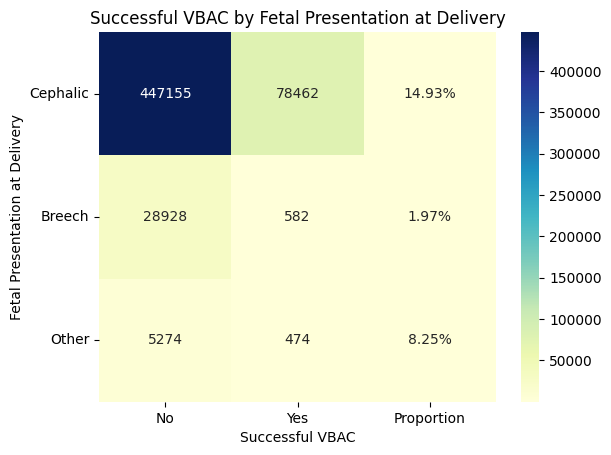

In [31]:
fetal_presentation_at_delivery_cross_tab = pd.crosstab(
    df["fetal_presentation_at_delivery"], target
)

fetal_presentation_at_delivery_cross_tab["proportion"] = (
    fetal_presentation_at_delivery_cross_tab[1]
    / (
        fetal_presentation_at_delivery_cross_tab[0]
        + fetal_presentation_at_delivery_cross_tab[1]
    )
    * 100
)

annotation_matrix = fetal_presentation_at_delivery_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    fetal_presentation_at_delivery_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

fetal_presentation_at_delivery_cross_tab_ax = sns.heatmap(
    fetal_presentation_at_delivery_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
fetal_presentation_at_delivery_cross_tab_ax.set_title(
    "Successful VBAC by Fetal Presentation at Delivery"
)
fetal_presentation_at_delivery_cross_tab_ax.set_xlabel("Successful VBAC")
fetal_presentation_at_delivery_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
fetal_presentation_at_delivery_cross_tab_ax.set_ylabel("Fetal Presentation at Delivery")
fetal_presentation_at_delivery_cross_tab_ax.set_yticklabels(
    ["Cephalic", "Breech", "Other"], rotation=0
)
plt.show()

Cephalic presentation has the highest VBAC success rate, which is expected.

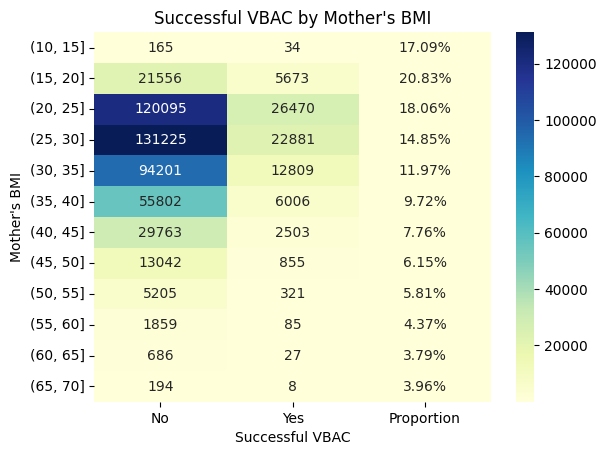

In [32]:
BMI_cross_tab = pd.crosstab(pd.cut(df["BMI"], bins=range(0, 100, 5)), target)
BMI_cross_tab["proportion"] = (
    BMI_cross_tab[1] / (BMI_cross_tab[0] + BMI_cross_tab[1])
) * 100

annotation_matrix = BMI_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(BMI_cross_tab["proportion"], 2)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

BMI_cross_tab_ax = sns.heatmap(
    BMI_cross_tab, annot=annotation_matrix.values, fmt="", cmap="YlGnBu"
)
BMI_cross_tab_ax.set_title("Successful VBAC by Mother's BMI")
BMI_cross_tab_ax.set_xlabel("Successful VBAC")
BMI_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
BMI_cross_tab_ax.set_ylabel("Mother's BMI")
BMI_cross_tab_ax.set_yticklabels(BMI_cross_tab.index.astype(str), rotation=0)
plt.show()

The higher a mother's BMI, the less likely she is to have a successful VBAC.

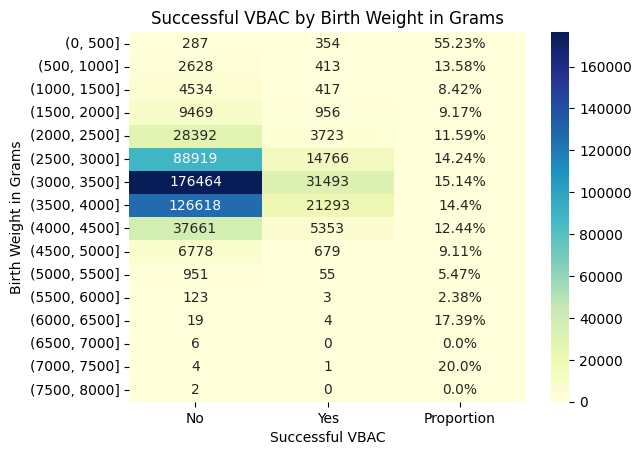

In [33]:
birth_weight_in_grams_cross_tab = pd.crosstab(
    pd.cut(df["birth_weight_in_grams"], bins=range(0, 8001, 500)), target
)
birth_weight_in_grams_cross_tab["proportion"] = (
    birth_weight_in_grams_cross_tab[1]
    / (birth_weight_in_grams_cross_tab[0] + birth_weight_in_grams_cross_tab[1])
) * 100

annotation_matrix = birth_weight_in_grams_cross_tab.copy()
annotation_matrix[0:2] = annotation_matrix[0:2].astype(int)
annotation_matrix["proportion"] = round(
    birth_weight_in_grams_cross_tab["proportion"], 2
)
annotation_matrix["proportion"] = annotation_matrix["proportion"].astype(str) + "%"

birth_weight_in_grams_cross_tab_ax = sns.heatmap(
    birth_weight_in_grams_cross_tab,
    annot=annotation_matrix.values,
    fmt="",
    cmap="YlGnBu",
)
birth_weight_in_grams_cross_tab_ax.set_title("Successful VBAC by Birth Weight in Grams")
birth_weight_in_grams_cross_tab_ax.set_xlabel("Successful VBAC")
birth_weight_in_grams_cross_tab_ax.set_xticklabels(["No", "Yes", "Proportion"])
birth_weight_in_grams_cross_tab_ax.set_ylabel("Birth Weight in Grams")
birth_weight_in_grams_cross_tab_ax.set_yticklabels(
    birth_weight_in_grams_cross_tab.index.astype(str), rotation=0
)
plt.show()

Of healthy birth weights (above 2500 grams), successful VBACS appear to be approximately proportional to the number of c-sections. Important to note, infants with birth weights below 2500 grams are likely to be premature or miscarried, and infants with birth weights above 5000 grams are uncommon enough that we may discount them as outliers.

### 4. Multivariate Visualizations

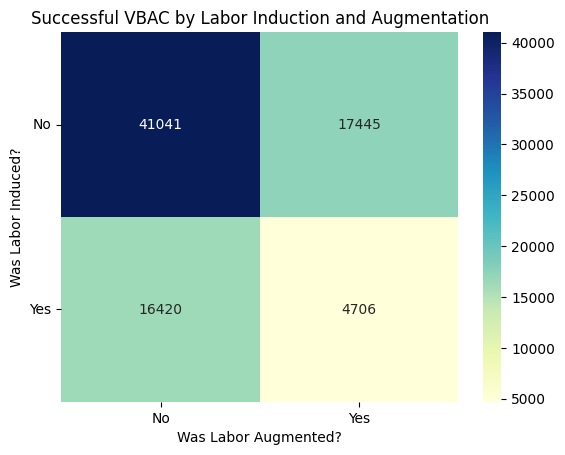

In [34]:
induction_augmentation_cross_tab = pd.crosstab(
    df["induction_of_labor"],
    df["augmentation_of_labor"],
    values=target,
    aggfunc="sum",
)

induction_augmentation_cross_tab_ax = sns.heatmap(
    induction_augmentation_cross_tab, annot=True, fmt="d", cmap="YlGnBu"
)
induction_augmentation_cross_tab_ax.set_title(
    "Successful VBAC by Labor Induction and Augmentation"
)
induction_augmentation_cross_tab_ax.set_xlabel("Was Labor Augmented?")
induction_augmentation_cross_tab_ax.set_xticklabels(["No", "Yes"])
induction_augmentation_cross_tab_ax.set_ylabel("Was Labor Induced?")
induction_augmentation_cross_tab_ax.set_yticklabels(["No", "Yes"], rotation=0)
plt.show()

Of our successful VBACs, the majority occurred naturally (as in, without induction or augmentation). About 3,600 occurred using both augmentation and induction. About 27,000 occurred with one or the other. We can conclude that both inducing and augmenting labor does not necessarily produce better results. This likely is because a birth attendant is unlikely to augment labor in a mother who has had a previous c-section, and instead opts for a repeat c-section.

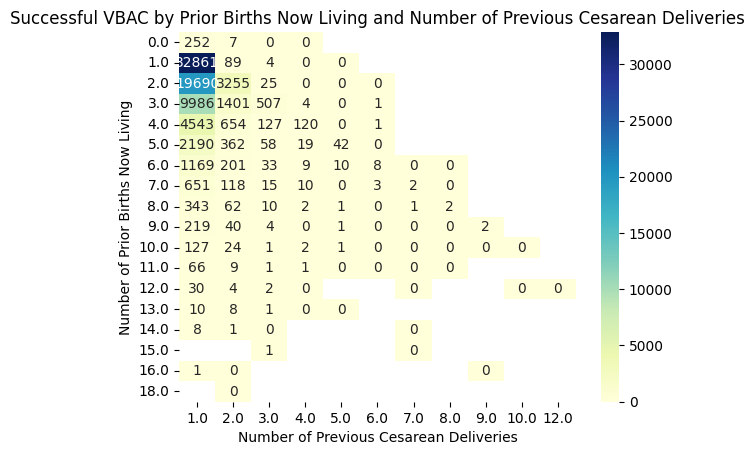

In [35]:
prior_births_previous_cesarean_cross_tab = pd.crosstab(
    df["prior_births_now_living"],
    df["number_of_previous_cesarean"],
    values=target,
    aggfunc="sum",
)

prior_births_previous_cesarean_cross_tab_ax = sns.heatmap(
    prior_births_previous_cesarean_cross_tab, annot=True, fmt=".0f", cmap="YlGnBu"
)
prior_births_previous_cesarean_cross_tab_ax.set_title(
    "Successful VBAC by Prior Births Now Living and Number of Previous Cesarean Deliveries"
)
prior_births_previous_cesarean_cross_tab_ax.set_xlabel(
    "Number of Previous Cesarean Deliveries"
)
prior_births_previous_cesarean_cross_tab_ax.set_xticklabels(
    prior_births_previous_cesarean_cross_tab.columns, rotation=0
)
prior_births_previous_cesarean_cross_tab_ax.set_ylabel(
    "Number of Prior Births Now Living"
)
prior_births_previous_cesarean_cross_tab_ax.set_yticklabels(
    prior_births_previous_cesarean_cross_tab.index, rotation=0
)
plt.show()

A successful VBAC is most likely to occur after 1 previous c-section. The more prior births and c-sections that have occurred, the less likely a successful VBAC becomes.

### Conclusion

Based on our findings, we'll move on with the following feature set:

- Augmentation of Labor
- Induction of Labor
- Number of Previous Cesarean
- Combined (Gestational Age) Gestation Detail in Weeks
- Prior Births Now Living
- Fetal Presentation at Delivery
- BMI

In [36]:
root = tk.Tk()
root.withdraw()

save_path = tk.filedialog.askdirectory(
    title="Select Folder to Save Chart JSON Files",
)

augmentation_of_labor_cross_tab.to_json(
    f"{save_path}/augmentation_of_labor_cross_tab.json"
)
attendant_at_birth_cross_tab.to_json(f"{save_path}/attendant_at_birth_cross_tab.json")
induction_of_labor_cross_tab.to_json(f"{save_path}/induction_of_labor_cross_tab.json")
time_of_birth_cross_tab.to_json(f"{save_path}/time_of_birth_cross_tab.json")
number_of_previous_cesarean_cross_tab.to_json(
    f"{save_path}/number_of_previous_cesarean_cross_tab.json"
)
birth_place_cross_tab.to_json(f"{save_path}/birth_place_cross_tab.json")
combined_gestation_detail_cross_tab.to_json(
    f"{save_path}/combined_gestation_detail_cross_tab.json"
)
prior_births_now_living_cross_tab.to_json(
    f"{save_path}/prior_births_now_living_cross_tab.json"
)
birth_day_of_week_cross_tab.to_json(f"{save_path}/birth_day_of_week_cross_tab.json")
fetal_presentation_at_delivery_cross_tab.to_json(
    f"{save_path}/fetal_presentation_at_delivery_cross_tab.json"
)
BMI_cross_tab.to_json(f"{save_path}/BMI_cross_tab.json")
birth_weight_in_grams_cross_tab.to_json(
    f"{save_path}/birth_weight_in_grams_cross_tab.json"
)